Notebook 7: BETO — Monolingual Spanish Anchor

Two conditions, from one training run:

`beto_es_only`  Spanish (4,141)

`beto_es2en`  (9,843)


## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
REPO = "Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-"
if not os.path.exists(f'/content/drive/MyDrive/{REPO}'):
    !cd /content/drive/MyDrive/ && git clone https://github.com/YusrahS/{REPO}
else:
    !git -C /content/drive/MyDrive/{REPO} checkout main && git -C /content/drive/MyDrive/{REPO} pull origin main

!ln -sf /content/drive/MyDrive/{REPO} /content/{REPO}
%cd /content/{REPO}

DRIVE = f'/content/drive/MyDrive/{REPO}'
DATA_DIR= f'{DRIVE}/data'


D =f'{DRIVE}/bilingual results'
M='/content/drive/MyDrive/cyberbullying_models'
assert os.path.isdir(D), f"results folder not found: {D}"
os.makedirs(M, exist_ok=True)
os.makedirs('reports/results', exist_ok=True)
os.makedirs('reports/figures', exist_ok=True)

print("results ->", D)
print("models  ->", M)


Mounted at /content/drive
M	data/english_transformer_data.pkl
Already on 'main'
Your branch is up to date with 'origin/main'.
From https://github.com/YusrahS/Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-
 * branch            main       -> FETCH_HEAD
Already up to date.
/content/drive/MyDrive/Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-
results -> /content/drive/MyDrive/Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-/bilingual results
models  -> /content/drive/MyDrive/cyberbullying_models


In [ ]:
import pandas as pd
import numpy as np
import pickle
import torch
import shutil
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import json
import os
from scipy.special import softmax


In [ ]:
with open(f'{DATA_DIR}/spanish_transformer_data.pkl', 'rb') as f:
    spanish_data = pickle.load(f)

spanish_train_texts = spanish_data['train_texts']
spanish_validation_texts = spanish_data['val_texts']
spanish_test_texts= spanish_data['test_texts']
spanish_train_labels = spanish_data['train_labels']
spanish_validation_labels= spanish_data['val_labels']
spanish_test_labels= spanish_data['test_labels']

with open(f'{DATA_DIR}/english_transformer_data.pkl', 'rb') as f:
    english_data = pickle.load(f)

english_test_texts= english_data['test_texts']
english_test_labels =english_data['test_labels']

print(f"Spanish train:{len(spanish_train_texts)} samples")
print(f"Spanish val:{len(spanish_validation_texts)} samples")
print(f"Spanish test:{len(spanish_test_texts)} samples")
print(f"English test:{len(english_test_texts)} samples (for ES->EN cross-lingual)")


In [ ]:
class CyberbullyingDataset(Dataset):
    def __init__(self,encodings, labels):
        self.encodings= encodings
        self.labels= labels
    def __getitem__(self, idx):
        item ={key: val[idx] for key, val in self.encodings.items()}
        item['labels'] =torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

def compute_metrics(eval_pred):
    predictions,labels = eval_pred
    predictions =np.argmax(predictions, axis=1)
    return {
        'accuracy':accuracy_score(labels, predictions),
        'f1':f1_score(labels, predictions, average='macro'),
        'precision':precision_score(labels, predictions, average='macro'),
        'recall':recall_score(labels, predictions, average='macro'),
    }

def evaluate_model(trainer, dataset, true_labels,condition_name):
    output= trainer.predict(dataset)
    probs= torch.softmax(torch.tensor(output.predictions),dim=1).numpy()
    pred_labels= np.argmax(output.predictions, axis=1)

    print(f"\n{'='*60}")
    print(f"  {condition_name}")
    print(f"{'='*60}")
    print(f"  Accuracy:{accuracy_score(true_labels, pred_labels):.4f}")
    print(f"  Macro Precision: {precision_score(true_labels, pred_labels, average='macro'):.4f}")
    print(f"  Macro Recall:{recall_score(true_labels, pred_labels, average='macro'):.4f}")
    print(f"  Macro F1:{f1_score(true_labels, pred_labels, average='macro'):.4f}")
    print(classification_report(true_labels, pred_labels, target_names=['Non-Abusive', 'Abusive']))

    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Abusive', 'Abusive'],yticklabels=['Non-Abusive', 'Abusive'])
    plt.title(condition_name, fontsize=11, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return pred_labels, probs

In [ ]:
def save_run(tag, preds, raw, labels, texts):
    raw =np.asarray(raw,dtype=np.float64)
    probs=softmax(raw, axis=1) if not np.allclose(raw.sum(1), 1, atol=1e-3) else raw
    assert probs[:, 1].max() > 0.75, f"{tag}: probabilities look softmaxed twice"
    np.save(f'{D}/{tag}_preds.npy', np.asarray(preds))
    np.save(f'{D}/{tag}_probs.npy',probs.astype(np.float32))
    np.save(f'{D}/{tag}_labels.npy',np.asarray(labels))
    rep = classification_report(labels, preds, target_names=['Non-Abusive', 'Abusive'],output_dict=True, digits=4)
    json.dump(rep, open(f'{D}/{tag}_metrics.json', 'w'), indent=2)
    pd.DataFrame({'text': texts, 'true': labels, 'pred': preds,'prob_abusive': probs[:, 1]}).to_csv(f'{D}/{tag}_samples.csv', index=False)
    print(f"{tag:22s} n={len(preds):6d} macroF1 {rep['macro avg']['f1-score']:.4f} "
          f"NonAb {rep['Non-Abusive']['recall']:.4f} Ab {rep['Abusive']['recall']:.4f}")
    return rep

Train on Spanish, evaluate on Spanish


Loading BETO from: dccuchile/bert-base-spanish-wwm-cased


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.314642,0.258397,0.894711,0.894679,0.895214,0.894716
2,0.189255,0.296037,0.898092,0.897942,0.900430,0.898083
3,0.106410,0.421747,0.903888,0.903877,0.904072,0.903885


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  BETO — ES-only monolingual (train ES, test ES)
  Accuracy:        0.8991
  Macro Precision: 0.8994
  Macro Recall:    0.8991
  Macro F1:        0.8990
              precision    recall  f1-score   support

 Non-Abusive       0.91      0.88      0.90      2071
     Abusive       0.89      0.91      0.90      2070

    accuracy                           0.90      4141
   macro avg       0.90      0.90      0.90      4141
weighted avg       0.90      0.90      0.90      4141



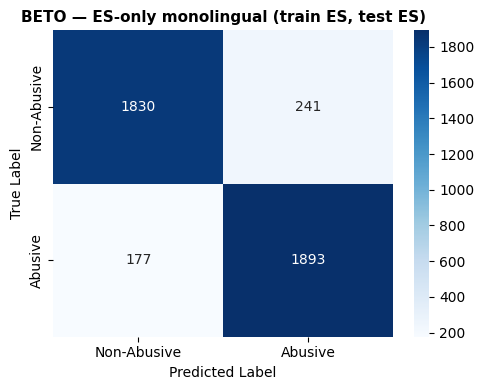

In [ ]:
BETO_CHECKPOINT = 'dccuchile/bert-base-spanish-wwm-cased'
print(f"Loading BETO from: {BETO_CHECKPOINT}")
beto_tokenizer =AutoTokenizer.from_pretrained(BETO_CHECKPOINT)
beto_model= AutoModelForSequenceClassification.from_pretrained(BETO_CHECKPOINT, num_labels=2)

beto_train_enc= beto_tokenizer(spanish_train_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')
beto_val_enc= beto_tokenizer(spanish_validation_texts, truncation=True, padding=True,
                                max_length=128, return_tensors='pt')
beto_test_enc= beto_tokenizer(spanish_test_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')

beto_train_dataset= CyberbullyingDataset(beto_train_enc,spanish_train_labels)
beto_val_dataset=CyberbullyingDataset(beto_val_enc,spanish_validation_labels)
beto_test_dataset= CyberbullyingDataset(beto_test_enc,spanish_test_labels)

training_args = TrainingArguments(
    output_dir='./results/beto',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    seed= 42,
)

beto_trainer = Trainer(
    model=beto_model,
    args=training_args,
    train_dataset=beto_train_dataset,
    eval_dataset=beto_val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

beto_trainer.train()
beto_es_preds, beto_es_probs = evaluate_model(
    beto_trainer, beto_test_dataset, spanish_test_labels,"BETO — ES-only monolingual (train ES, test ES)")

In [ ]:
save_run('beto_es_only', beto_es_preds, beto_es_probs,
         spanish_test_labels, spanish_test_texts)
beto_model.save_pretrained(f'{M}/beto_es_only')
beto_tokenizer.save_pretrained(f'{M}/beto_es_only')
print("model saved to", f'{M}/beto_es_only')

beto_es_only           n=  4141 macroF1 0.8990 NonAb 0.8836 Ab 0.9145


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

model saved to /content/drive/MyDrive/cyberbullying_models/beto_es_only


 ES→EN cross-lingual



  BETO — ES→EN cross-lingual (train ES, test EN)
  Accuracy:        0.6345
  Macro Precision: 0.6594
  Macro Recall:    0.6343
  Macro F1:        0.6194
              precision    recall  f1-score   support

 Non-Abusive       0.60      0.83      0.70      4926
     Abusive       0.72      0.44      0.54      4917

    accuracy                           0.63      9843
   macro avg       0.66      0.63      0.62      9843
weighted avg       0.66      0.63      0.62      9843



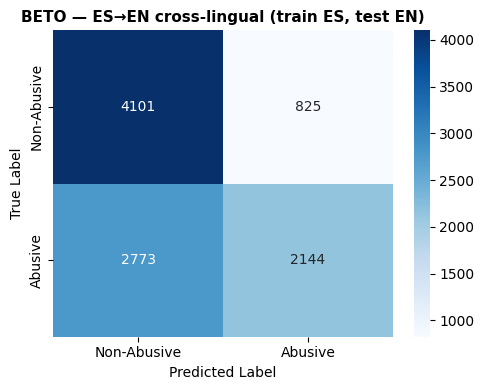

beto_es2en             n=  9843 macroF1 0.6194 NonAb 0.8325 Ab 0.4360


{'Non-Abusive': {'precision': 0.5965958684899622,
  'recall': 0.8325213154689404,
  'f1-score': 0.6950847457627118,
  'support': 4926.0},
 'Abusive': {'precision': 0.7221286628494442,
  'recall': 0.4360382346959528,
  'f1-score': 0.5437484149125031,
  'support': 4917.0},
 'accuracy': 0.6344610383013309,
 'macro avg': {'precision': 0.6593622656697031,
  'recall': 0.6342797750824466,
  'f1-score': 0.6194165803376075,
  'support': 9843.0},
 'weighted avg': {'precision': 0.6593048748767928,
  'recall': 0.6344610383013309,
  'f1-score': 0.6194857679317177,
  'support': 9843.0}}

In [ ]:
beto_en_test_enc=beto_tokenizer(english_test_texts, truncation=True, padding=True,max_length=128, return_tensors='pt')
beto_en_test_dataset =CyberbullyingDataset(beto_en_test_enc, english_test_labels)
beto_en_preds,beto_en_probs = evaluate_model(
    beto_trainer,beto_en_test_dataset, english_test_labels,"BETO — ES→EN cross-lingual (train ES, test EN)")

save_run('beto_es2en', beto_en_preds, beto_en_probs,english_test_labels, english_test_texts)

The specialist comparison


In [4]:
def _report(tag):
    for folder in D:
        p = f'{folder}/{tag}_metrics.json'
        if os.path.exists(p):
            return json.load(open(p))
    return None

def f1_of(tag):
    d =_report(tag)
    return round(d['macro avg']['f1-score'], 4) if d else None

def recalls_of(tag):
    d= _report(tag)
    if not d: return None, None
    return round(d['Non-Abusive']['recall'], 4), round(d['Abusive']['recall'], 4)

rows = []
for tag,name, typ in [('beto_es_only','BETO','Monolingual ES'), ('distilbert_es_only', 'DistilBERT', 'Multilingual'),
                       ('mbert_es_only','mBERT','Multilingual'),('xlmr_es_only','XLM-R','Multilingual')]:
    na, ab =recalls_of(tag)
    rows.append({'Model': name,'Type': typ,'ES-only F1': f1_of(tag),
                 'Non-Ab recall': na,'Abusive recall': ab})

comp = (pd.DataFrame(rows).sort_values('ES-only F1', ascending=False, na_position='last').reset_index(drop=True))
comp.to_csv('beto_vs_multilingual_es_only.csv', index=False)
print("Spanish monolingual (ES-only), 4,141 test rows")
print(comp.to_string(index=False))

missing= [r['Model'] for r in rows if r['ES-only F1'] is None]
if missing:
    print("\nnot yet in the results folder:", ", ".join(missing))

Spanish monolingual (ES-only), 4,141 test rows
     Model           Type  ES-only F1  Non-Ab recall  Abusive recall
      BETO Monolingual ES      0.8990         0.8836          0.9145
     XLM-R   Multilingual      0.8860         0.8933          0.8787
     mBERT   Multilingual      0.8773         0.8745          0.8802
DistilBERT   Multilingual      0.8684         0.8556          0.8812


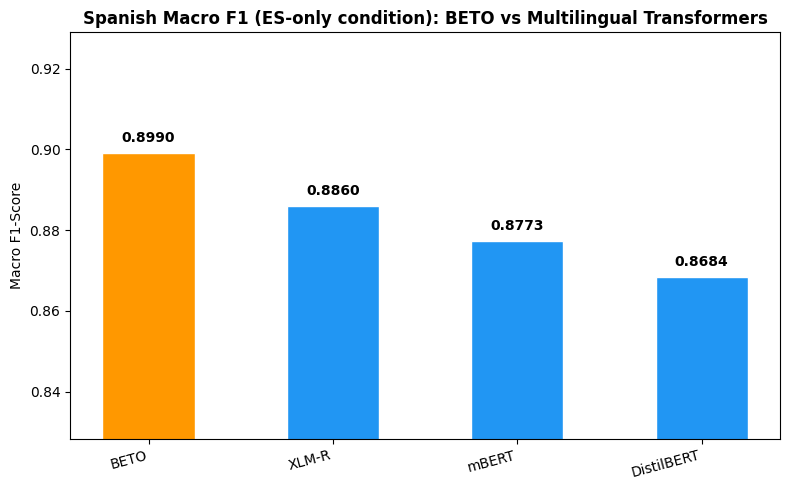

In [ ]:
plot_df=comp.dropna(subset=['ES-only F1'])

plt.figure(figsize=(8, 5))
colors =['#FF9800' if t == 'Monolingual ES' else '#2196F3' for t in plot_df['Type']]
bars = plt.bar(plot_df['Model'], plot_df['ES-only F1'], color=colors,edgecolor='white', width=0.5)
plt.title('Spanish Macro F1 (ES-only condition): BETO vs Multilingual Transformers', fontsize=12, fontweight='bold')
plt.ylabel('Macro F1-Score')
lo = plot_df['ES-only F1'].min()
plt.ylim(max(0, lo - 0.04), min(1.0, plot_df['ES-only F1'].max() + 0.03))
for b, s in zip(bars, plot_df['ES-only F1']):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.002, f'{s:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('reports/figures/beto_vs_multilingual_es_only.png', dpi=300, bbox_inches='tight')
plt.show()

ES→EN transfer

In [ ]:
rows= []
for tag, name in [('beto_es2en','BETO (monolingual ES)'),
                  ('distilbert_es2en', 'DistilBERT'),('mbert_es2en','mBERT'), ('xlmr_es2en','XLM-R')]:
    na, ab =recalls_of(tag)
    rows.append({'Model': name, 'ES->EN F1': f1_of(tag),'Non-Ab recall': na, 'Abusive recall': ab})

xl =pd.DataFrame(rows).sort_values('ES->EN F1', ascending=False, na_position='last')
xl.to_csv('reports/results/es2en_comparison.csv', index=False)
print("ES->EN cross-lingual, 9,843 English test rows")
print(xl.to_string(index=False))

if f1_of('beto_es_only') and f1_of('beto_es2en'):
    drop = 100 * (f1_of('beto_es_only') - f1_of('beto_es2en'))
    print(f"\nBETO transfer cost: {f1_of('beto_es_only'):.4f} in-language -> "
          f"{f1_of('beto_es2en'):.4f} transferred ({drop:.1f} pp)")

ES->EN cross-lingual, 9,843 English test rows
                Model  ES->EN F1  Non-Ab recall  Abusive recall
                XLM-R     0.6313         0.8831          0.4190
BETO (monolingual ES)     0.6194         0.8325          0.4360
                mBERT     0.5456         0.8985          0.2794
           DistilBERT     0.5396         0.8843          0.2790

BETO transfer cost: 0.8990 in-language -> 0.6194 transferred (28.0 pp)


### Transfer cost across all models


In [5]:
rows =[]
for tag_es,tag_x,name in [('beto_es_only','beto_es2en','BETO (monolingual ES)'), ('xlmr_es_only','xlmr_es2en','XLM-R'),
                            ('mbert_es_only','mbert_es2en','mBERT'),
                            ('distilbert_es_only', 'distilbert_es2en', 'DistilBERT'),('bilstm_es_only','bilstm_es2en','BiLSTM')]:
    a, b= f1_of(tag_es),f1_of(tag_x)
    if a is None or b is None:
        print(f"  skipped {name}: missing {'ES-only' if a is None else 'ES→EN'}")
        continue
    rows.append({'Model': name, 'ES-only': a, 'ES→EN': b,'Transfer cost (pp)': round(100 * (a - b), 1)})

cost = pd.DataFrame(rows).sort_values('Transfer cost (pp)')
cost.to_csv('reports/results/transfer_cost.csv', index=False)
print("In-language performance against transferred performance\n")
print(cost.to_string(index=False))


In-language performance against transferred performance

                Model  ES-only  ES→EN  Transfer cost (pp)
                XLM-R   0.8860 0.6313                25.5
BETO (monolingual ES)   0.8990 0.6194                28.0
               BiLSTM   0.7691 0.4462                32.3
           DistilBERT   0.8684 0.5396                32.9
                mBERT   0.8773 0.5456                33.2


Summary

In [ ]:
print("=" * 62)
print("  BETO RESULTS")
print("=" * 62)
print(f"  ES-only monolingual  macro F1  {f1_of('beto_es_only'):.4f}")
print(f"  ES->EN cross-lingual  macro F1  {f1_of('beto_es2en'):.4f}")
print()
print(comp.to_string(index=False))
print()
print(xl.to_string(index=False))
print("=" * 62)

  BETO RESULTS
  ES-only monolingual   macro F1  0.8990
  ES->EN cross-lingual  macro F1  0.6194

     Model           Type  ES-only F1  Non-Ab recall  Abusive recall
      BETO Monolingual ES      0.8990         0.8836          0.9145
     XLM-R   Multilingual      0.8860         0.8933          0.8787
     mBERT   Multilingual      0.8773         0.8745          0.8802
DistilBERT   Multilingual      0.8684         0.8556          0.8812

                Model  ES->EN F1  Non-Ab recall  Abusive recall
                XLM-R     0.6313         0.8831          0.4190
BETO (monolingual ES)     0.6194         0.8325          0.4360
                mBERT     0.5456         0.8985          0.2794
           DistilBERT     0.5396         0.8843          0.2790
